# ScanFold2 Runtime Analysis

Two questions:
1. **Dataset length distribution** — what fraction of transcripts exceed various length thresholds?
2. **Runtime vs sequence length** — validate the O(n²) fold-step claim and calibrate SLURM resource requests.

**Data sources**
- `resources/gencode.v47.repeat.simple.fa` — input FASTA (16,955 sequences)
- `results/gencode.v47.repeat.simple/scanfold2_gpu/*/ScanFold_run.log` — per-batch logs with cumulative elapsed times

**Log format note:** elapsed times are cumulative since batch start; per-sequence time = difference between consecutive `ScanFold completed` entries.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy.optimize import curve_fit

REPO = Path("..").resolve()
FASTA = REPO / "resources/gencode.v47.repeat.simple.fa"
GPU_DIR = REPO / "results/gencode.v47.repeat.simple/scanfold2_gpu"

assert FASTA.exists(), f"FASTA not found: {FASTA}"
assert GPU_DIR.exists(), f"Results dir not found: {GPU_DIR}"
print("Paths OK")

Paths OK


## 1. Dataset length distribution

In [ ]:
def parse_fasta_lengths(fasta_path):
    """Return DataFrame indexed by seq_id with column seq_len_nt."""
    lengths = {}
    current_id = None
    current_len = 0
    with open(fasta_path) as fh:
        for line in fh:
            line = line.rstrip()
            if line.startswith(">"):
                if current_id is not None:
                    lengths[current_id] = current_len
                current_id = line[1:].split()[0]
                current_len = 0
            else:
                current_len += len(line)
    if current_id is not None:
        lengths[current_id] = current_len
    return pd.DataFrame(
        list(lengths.items()), columns=["seq_id", "seq_len_nt"]
    ).set_index("seq_id")


df_len = parse_fasta_lengths(FASTA)

print(f"Total sequences : {len(df_len):,}")
print(f"Min length      : {df_len.seq_len_nt.min():,} nt")
print(f"Median length   : {df_len.seq_len_nt.median():,.0f} nt")
print(f"Mean length     : {df_len.seq_len_nt.mean():,.0f} nt")
print(f"Max length      : {df_len.seq_len_nt.max():,} nt")

Total sequences : 16,955
Min length      : 20 nt
Median length   : 1,429 nt
Mean length     : 2,029 nt
Max length      : 347,561 nt


In [ ]:
# Threshold table
total = len(df_len)
rows = []
for t in [10_000, 20_000, 50_000, 100_000, 200_000]:
    n_above = (df_len.seq_len_nt > t).sum()
    pct_above = n_above / total * 100
    rows.append(
        {
            "Threshold (nt)": f"{t:,}",
            "# above": f"{n_above:,}",
            "% above": f"{pct_above:.3f}%",
            "% below (safe)": f"{100 - pct_above:.3f}%",
        }
    )

pd.DataFrame(rows)

,Threshold (nt),# above,% above,% below (safe)
0,"10,000",79,0.466%,99.534%
1,"20,000",10,0.059%,99.941%
2,"50,000",6,0.035%,99.965%
3,"100,000",6,0.035%,99.965%
4,"200,000",1,0.006%,99.994%


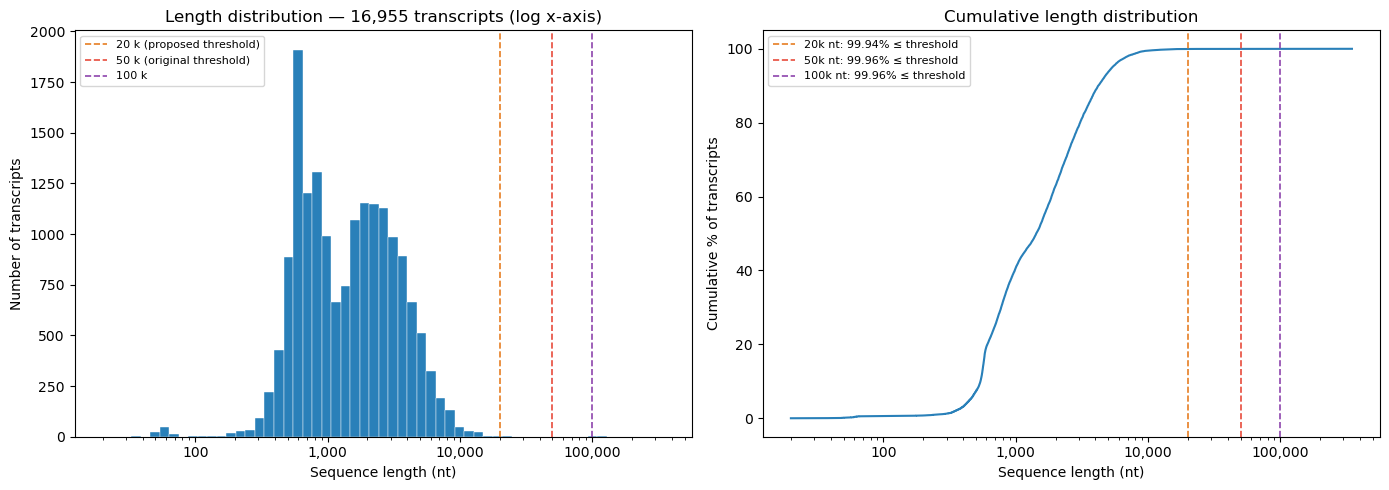

In [ ]:
VLINES = [
    (20_000,  "#e67e22", "20 k (proposed threshold)"),
    (50_000,  "#e74c3c", "50 k (original threshold)"),
    (100_000, "#8e44ad", "100 k"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (log x-axis)
ax = axes[0]
bins = np.logspace(
    np.log10(df_len.seq_len_nt.min()),
    np.log10(df_len.seq_len_nt.max()),
    60,
)
ax.hist(df_len.seq_len_nt, bins=bins, color="#2980b9", edgecolor="white", linewidth=0.3)
for x, color, label in VLINES:
    ax.axvline(x, color=color, linestyle="--", linewidth=1.2, label=label)
ax.set_xscale("log")
ax.set_xlabel("Sequence length (nt)")
ax.set_ylabel("Number of transcripts")
ax.set_title(f"Length distribution — {total:,} transcripts (log x-axis)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# CDF
ax = axes[1]
sorted_lens = np.sort(df_len.seq_len_nt.values)
cdf = np.arange(1, len(sorted_lens) + 1) / len(sorted_lens) * 100
ax.plot(sorted_lens, cdf, color="#2980b9", linewidth=1.5)
for x, color, label in VLINES:
    pct_below = (df_len.seq_len_nt <= x).mean() * 100
    ax.axvline(
        x, color=color, linestyle="--", linewidth=1.2,
        label=f"{int(x/1000)}k nt: {pct_below:.2f}% ≤ threshold",
    )
ax.set_xscale("log")
ax.set_xlabel("Sequence length (nt)")
ax.set_ylabel("Cumulative % of transcripts")
ax.set_title("Cumulative length distribution")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("scanfold_length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Per-sequence runtime from ScanFold logs

Each `ScanFold_run.log` records **cumulative** elapsed time since job start.  
Per-sequence time = `elapsed[i] − elapsed[i−1]` (first sequence uses `elapsed[0]` directly).

The sequence ID is extracted from the `Results README created: batch_XXXXX.ENST*.README.md` line that follows each completion entry.

In [ ]:
RE_DONE = re.compile(r"\[[\d:]+\] ScanFold completed\. Elapsed time: ([\d.]+)s")
RE_README = re.compile(r"Results README created: [^.]+\.([^.]+\.[^.]+)\.README\.md")


def parse_scanfold_log(log_path):
    """Return list of dicts: seq_id, time_s (per-sequence), elapsed_cumulative_s."""
    records = []
    elapsed_prev = 0.0
    lines = Path(log_path).read_text().splitlines()
    for i, line in enumerate(lines):
        m = RE_DONE.search(line)
        if not m:
            continue
        elapsed_done = float(m.group(1))
        per_seq = elapsed_done - elapsed_prev
        elapsed_prev = elapsed_done
        seq_id = None
        for j in range(i + 1, min(i + 6, len(lines))):
            m2 = RE_README.search(lines[j])
            if m2:
                seq_id = m2.group(1)
                break
        if seq_id:
            records.append(
                {
                    "seq_id": seq_id,
                    "time_s": per_seq,
                    "elapsed_cumulative_s": elapsed_done,
                }
            )
    return records


all_records = []
for batch_dir in sorted(GPU_DIR.iterdir()):
    log_path = batch_dir / "ScanFold_run.log"
    if not log_path.exists():
        continue
    records = parse_scanfold_log(log_path)
    for r in records:
        r["batch"] = batch_dir.name
    all_records.extend(records)

df_rt = pd.DataFrame(all_records)
print(f"Batches with completed sequences : {df_rt.batch.nunique()}")
print(f"Total completed sequences        : {len(df_rt):,}")
print(f"Time range (per sequence)        : {df_rt.time_s.min():.1f} s – {df_rt.time_s.max():,.0f} s")
print(f"                                   {df_rt.time_s.min()/3600:.4f} h – {df_rt.time_s.max()/3600:.2f} h")

Batches with completed sequences : 26
Total completed sequences        : 16,115
Time range (per sequence)        : 0.2 s – 59,812 s
                                   0.0000 h – 16.61 h


In [ ]:
# Join runtimes with sequence lengths
df_rt = df_rt.join(df_len, on="seq_id", how="left")

n_missing = df_rt.seq_len_nt.isna().sum()
if n_missing:
    print(f"WARNING: {n_missing} seq_ids not found in FASTA:")
    print(df_rt[df_rt.seq_len_nt.isna()][["seq_id", "batch"]].to_string())
else:
    print("All sequences matched to FASTA lengths.")

df_rt = df_rt.dropna(subset=["seq_len_nt"])
print(f"\nDataset for modelling: {len(df_rt):,} sequences")
display(
    df_rt[["seq_id", "batch", "seq_len_nt", "time_s"]]
    .sort_values("seq_len_nt", ascending=False)
    .head(10)
)

All sequences matched to FASTA lengths.

Dataset for modelling: 16,115 sequences


,seq_id,batch,seq_len_nt,time_s
2226,ENST00000412264.2,batch_00002_retry_00000,109488,54851.37
2224,ENST00000425332.3,batch_00002,109140,58910.20
2225,ENST00000426232.6,batch_00002,108666,59812.12
8656,ENST00000501122.3,batch_00008,23263,1846.63
2234,ENST00000681139.1,batch_00002_retry_00000,21051,1570.55
11176,ENST00000680313.1,batch_00011,20066,1658.20
11175,ENST00000684561.1,batch_00011,20045,1508.53
10130,ENST00000623210.1,batch_00010,18662,1410.53
1350,ENST00000609119.2,batch_00001,16525,1016.51
5197,ENST00000696229.1,batch_00005,16183,932.44


## 3. Runtime model: O(n) scan + O(n²) fold

ScanFold processes each transcript in two steps:

1. **ScanFold-Scan** (RNAfold + TF inference) — O(n) in sequence length.
2. **ScanFold-Fold** (`best_bps` partner detection loop) — O(n²): for each of the n nucleotides
   it builds a sub-dict of all n positions and calls `competing_pairs()` multiple times.

Total time is approximated by `t = a·n + b·n²`. We fit three variants and compare R².

In [ ]:
def model_linear(n, a):
    return a * n

def model_quadratic(n, b):
    return b * n ** 2

def model_linear_quadratic(n, a, b):
    return a * n + b * n ** 2

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot


n_obs = df_rt.seq_len_nt.values.astype(float)
t_obs = df_rt.time_s.values

popt_lin,  _ = curve_fit(model_linear,            n_obs, t_obs, p0=[1e-4])
popt_quad, _ = curve_fit(model_quadratic,         n_obs, t_obs, p0=[1e-9])
popt_lq,   _ = curve_fit(model_linear_quadratic,  n_obs, t_obs, p0=[1e-4, 1e-9])

r2_lin  = r2_score(t_obs, model_linear(n_obs, *popt_lin))
r2_quad = r2_score(t_obs, model_quadratic(n_obs, *popt_quad))
r2_lq   = r2_score(t_obs, model_linear_quadratic(n_obs, *popt_lq))

b_fit = popt_quad[0]  # coefficient for pure O(n²) model

print(f"O(n)    fit: a  = {popt_lin[0]:.4e}                  R² = {r2_lin:.4f}")
print(f"O(n²)   fit: b  = {b_fit:.4e}                  R² = {r2_quad:.4f}")
print(f"O(n+n²) fit: a  = {popt_lq[0]:.4e}, b = {popt_lq[1]:.4e}  R² = {r2_lq:.4f}")
print(f"\nUsing O(n²) model for extrapolation: t(s) = {b_fit:.4e} × n²")
print("(slightly over-predicts short sequences; conservative / safer for resource planning)")

O(n)    fit: a  = 1.5326e-01                  R² = 0.3389
O(n²)   fit: b  = 4.8612e-06                  R² = 0.9966
O(n+n²) fit: a  = 8.0562e-03, b = 4.7762e-06  R² = 0.9973

Using O(n²) model for extrapolation: t(s) = 4.8612e-06 × n²
(slightly over-predicts short sequences; conservative / safer for resource planning)


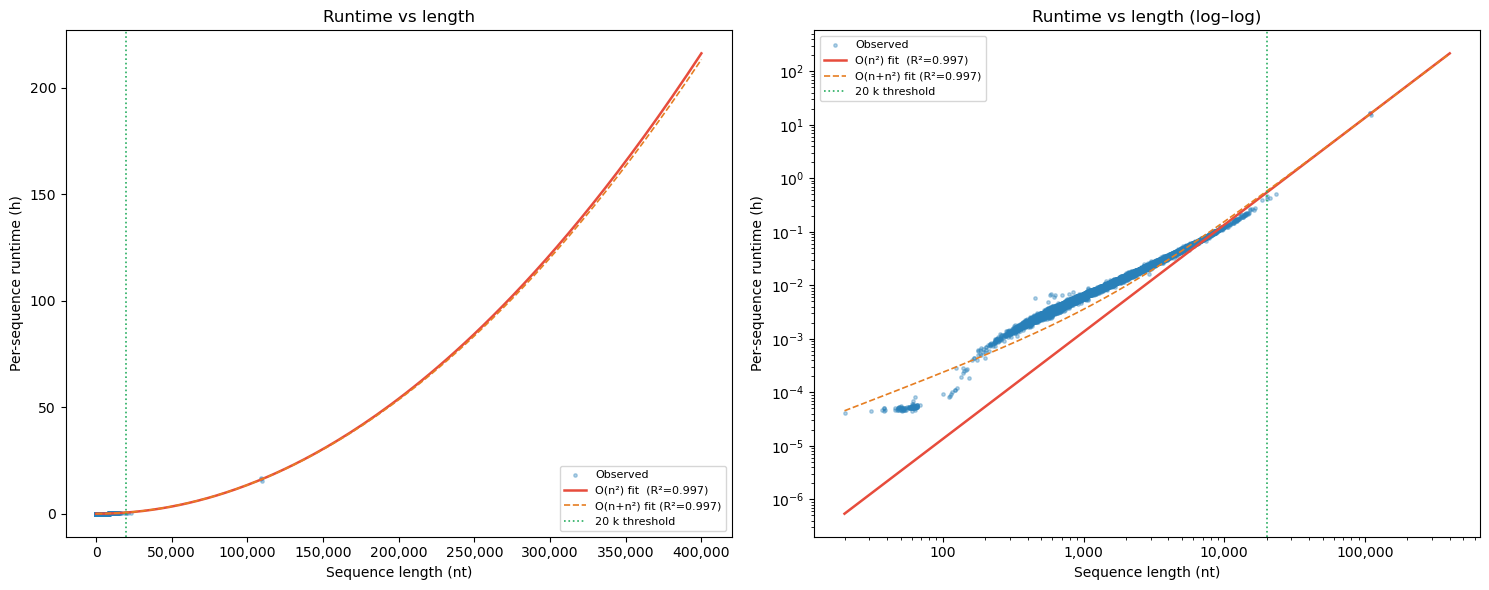

In [ ]:
n_grid = np.logspace(np.log10(n_obs.min()), np.log10(400_000), 400)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, log_scale in zip(axes, [False, True]):
    ax.scatter(
        df_rt.seq_len_nt, df_rt.time_s / 3600,
        alpha=0.35, s=6, color="#2980b9", label="Observed", zorder=2,
    )
    ax.plot(
        n_grid, model_quadratic(n_grid, b_fit) / 3600,
        color="#e74c3c", linewidth=1.8,
        label=f"O(n²) fit  (R²={r2_quad:.3f})",
    )
    ax.plot(
        n_grid, model_linear_quadratic(n_grid, *popt_lq) / 3600,
        color="#e67e22", linewidth=1.2, linestyle="--",
        label=f"O(n+n²) fit (R²={r2_lq:.3f})",
    )
    ax.axvline(20_000, color="#27ae60", linestyle=":", linewidth=1.2, label="20 k threshold")

    # Annotate the one confirmed long-sequence data point
    row = df_rt[df_rt.seq_id == "ENST00000446966.2"]
    if not row.empty:
        x_pt, y_pt = row.seq_len_nt.values[0], row.time_s.values[0] / 3600
        ax.scatter([x_pt], [y_pt], color="#8e44ad", s=60, zorder=5)
        ax.annotate(
            f"ENST00000446966.2\n({x_pt:,} nt, {y_pt:.1f} h)",
            xy=(x_pt, y_pt), xytext=(15, -20), textcoords="offset points",
            fontsize=7.5, color="#8e44ad",
            arrowprops=dict(arrowstyle="->", color="#8e44ad", lw=0.8),
        )

    if log_scale:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title("Runtime vs length (log–log)")
    else:
        ax.set_title("Runtime vs length")

    ax.set_xlabel("Sequence length (nt)")
    ax.set_ylabel("Per-sequence runtime (h)")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("scanfold_runtime_vs_length.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Threshold calibration and SLURM resource table

In [ ]:
def slurm_runtime(seconds):
    """Round up to a convenient SLURM runtime string."""
    days = seconds / 86400
    if days < 0.5:
        return f"{int(np.ceil(seconds / 3600))}h"
    elif days < 1.5:
        return "1d"
    elif days < 2.5:
        return "2d"
    elif days < 3.5:
        return "3d"
    else:
        return f"{int(np.ceil(days))}d"


KEY_LENGTHS = {
    "5,000 nt (typical short)": 5_000,
    "10,000 nt": 10_000,
    "20,000 nt (proposed threshold)": 20_000,
    "50,000 nt (original threshold)": 50_000,
    "100,000 nt (batch_00002 outliers)": 100_000,
    "109,068 nt (ENST00000446966.2 — observed)": 109_068,
    "200,000 nt": 200_000,
    "347,561 nt (ENST00000674361.1 — OOM)": 347_561,
}
SAFETY = 3.0  # 3× safety factor applied to SLURM runtime

rows = []
for label, n in KEY_LENGTHS.items():
    t_pred = model_quadratic(n, b_fit)
    t_safe = t_pred * SAFETY
    rows.append(
        {
            "Description": label,
            "Length (nt)": f"{n:,}",
            "Predicted time": f"{t_pred / 3600:.2f} h",
            f"{SAFETY:.0f}× safety": f"{t_safe / 3600:.2f} h",
            "Suggested SLURM runtime": slurm_runtime(t_safe),
        }
    )

display(pd.DataFrame(rows))

,Description,Length (nt),Predicted time,3× safety,Suggested SLURM runtime
0,"5,000 nt (typical short)","5,000",0.03 h,0.10 h,1h
1,"10,000 nt","10,000",0.14 h,0.41 h,1h
2,"20,000 nt (proposed threshold)","20,000",0.54 h,1.62 h,2h
3,"50,000 nt (original threshold)","50,000",3.38 h,10.13 h,11h
4,"100,000 nt (batch_00002 outliers)","100,000",13.50 h,40.51 h,2d
5,"109,068 nt (ENST00000446966.2 — observed)","109,068",16.06 h,48.19 h,2d
6,"200,000 nt","200,000",54.01 h,162.04 h,7d
7,"347,561 nt (ENST00000674361.1 — OOM)","347,561",163.12 h,489.36 h,21d


## 5. Validate architecture doc claims

The architecture doc states: *"sequences >20k nt are uncommon; those >50k nt are rare outliers (<<1%)"*.  
Check those numbers against the actual FASTA.

In [ ]:
n_total = len(df_len)

for t in [10_000, 20_000, 50_000, 100_000]:
    n_above = (df_len.seq_len_nt > t).sum()
    pct = n_above / n_total * 100
    qualifier = (
        "rare outlier (<1%)" if pct < 1
        else "uncommon (<5%)" if pct < 5
        else "common"
    )
    print(f">{t/1000:>5.0f} k nt : {n_above:>5,} seqs  ({pct:6.3f}%)  → {qualifier}")

>   10 k nt :    79 seqs  ( 0.466%)  → rare outlier (<1%)
>   20 k nt :    10 seqs  ( 0.059%)  → rare outlier (<1%)
>   50 k nt :     6 seqs  ( 0.035%)  → rare outlier (<1%)
>  100 k nt :     6 seqs  ( 0.035%)  → rare outlier (<1%)


In [ ]:
# All sequences above the proposed 20 k threshold, sorted longest first
long_seqs = (
    df_len[df_len.seq_len_nt > 20_000]
    .sort_values("seq_len_nt", ascending=False)
    .copy()
)
long_seqs["pred_time_h"] = model_quadratic(long_seqs.seq_len_nt, b_fit) / 3600
long_seqs["safe_time_h"] = long_seqs["pred_time_h"] * SAFETY
long_seqs["slurm_runtime"] = long_seqs["safe_time_h"].apply(lambda h: slurm_runtime(h * 3600))

print(f"Sequences > 20,000 nt: {len(long_seqs):,}")
display(long_seqs.head(30))

Sequences > 20,000 nt: 10


,seq_len_nt,pred_time_h,safe_time_h,slurm_runtime
seq_id,,,,
ENST00000674361.1,347561,163.119150,489.357451,21d
ENST00000412264.2,109488,16.187356,48.562068,2d
ENST00000425332.3,109140,16.084619,48.253856,2d
ENST00000446966.2,109068,16.063404,48.190211,2d
ENST00000426232.6,108666,15.945210,47.835629,2d
ENST00000591111.5,104301,14.689933,44.069799,2d
ENST00000501122.3,23263,0.730759,2.192278,3h
ENST00000681139.1,21051,0.598396,1.795187,2h
ENST00000680313.1,20066,0.543706,1.631119,2h


## 6. Summary

In [ ]:
SEP = "=" * 64

print(SEP)
print("DATASET (gencode.v47.repeat.simple)")
print(SEP)
print(f"Total transcripts: {n_total:,}")
for t in [10_000, 20_000, 50_000, 100_000]:
    n_above = (df_len.seq_len_nt > t).sum()
    print(f"  > {t/1000:>5.0f} k nt : {n_above:>4,}  ({n_above/n_total*100:.3f}%)")

print()
print(SEP)
print("RUNTIME MODEL")
print(SEP)
print(f"Fit (O(n²)): t(s) = {b_fit:.4e} × n²   R² = {r2_quad:.4f}")
print(f"Sequences modelled: {len(df_rt):,}")
obs_row = df_rt[df_rt.seq_id == "ENST00000446966.2"]
if not obs_row.empty:
    n_val = obs_row.seq_len_nt.values[0]
    t_val = obs_row.time_s.values[0]
    t_pred = model_quadratic(n_val, b_fit)
    print(f"  Observed:  ENST00000446966.2 ({n_val:,} nt) → {t_val/3600:.2f} h")
    print(f"  Predicted: {t_pred/3600:.2f} h  (error: {abs(t_val-t_pred)/t_val*100:.1f}%)")

print()
print(SEP)
print("THRESHOLD RECOMMENDATION")
print(SEP)
t_20k = model_quadratic(20_000, b_fit)
print(f"At 20k nt threshold:")
print(f"  Predicted per-sequence time : {t_20k:.0f} s = {t_20k/60:.1f} min")
print(f"  10-seq tertiary sub-batch   : ≤ {10*t_20k/60:.0f} min — fits in a 2d GPU job")
print()
if not obs_row.empty:
    t_109k = model_quadratic(109_068, b_fit)
    print(f"At 109k nt (oversized CPU job):")
    print(f"  Predicted : {t_109k/3600:.1f} h  |  Observed: {obs_row.time_s.values[0]/3600:.1f} h")
    print(f"  3× safety : {t_109k*3/3600:.1f} h — fits in a 5d job")

DATASET (gencode.v47.repeat.simple)
Total transcripts: 16,955
  >    10 k nt :   79  (0.466%)
  >    20 k nt :   10  (0.059%)
  >    50 k nt :    6  (0.035%)
  >   100 k nt :    6  (0.035%)

RUNTIME MODEL
Fit (O(n²)): t(s) = 4.8612e-06 × n²   R² = 0.9966
Sequences modelled: 16,115

THRESHOLD RECOMMENDATION
At 20k nt threshold:
  Predicted per-sequence time : 1944 s = 32.4 min
  10-seq tertiary sub-batch   : ≤ 324 min — fits in a 2d GPU job



## 7. Runtime forecast for an arbitrary input FASTA

Given any FASTA file, estimate per-sequence and total runtime using the fitted O(n²) model.

In [ ]:
# ── Configuration ────────────────────────────────────────────────────────────
FORECAST_FASTA = REPO / "results/gencode.v47.repeat.simple/scanfold_retry_batches/batch_00002_retry_00000.fa"
# ─────────────────────────────────────────────────────────────────────────────

def fmt_duration(seconds):
    """Format seconds as Xd Xh Xm Xs."""
    seconds = int(seconds)
    d, rem = divmod(seconds, 86400)
    h, rem = divmod(rem, 3600)
    m, s   = divmod(rem, 60)
    parts = []
    if d: parts.append(f"{d}d")
    if h: parts.append(f"{h}h")
    if m: parts.append(f"{m}m")
    parts.append(f"{s}s")
    return " ".join(parts)

df_forecast = parse_fasta_lengths(FORECAST_FASTA).reset_index()
df_forecast["est_s"]   = model_quadratic(df_forecast.seq_len_nt.values.astype(float), b_fit)
df_forecast["est_hms"] = df_forecast.est_s.apply(fmt_duration)
df_forecast = df_forecast.sort_values("seq_len_nt", ascending=False).reset_index(drop=True)
df_forecast.index += 1  # 1-based rank

total_s    = df_forecast.est_s.sum()
n_seqs     = len(df_forecast)
longest_s  = df_forecast.est_s.iloc[0]

print(f"FASTA       : {FORECAST_FASTA.name}")
print(f"Sequences   : {n_seqs:,}")
print(f"Total est.  : {fmt_duration(total_s)}  ({total_s/3600:.1f} h)")
print(f"Longest seq : {df_forecast.seq_len_nt.iloc[0]:,} nt → {fmt_duration(longest_s)}")
print()

display(
    df_forecast[["seq_id", "seq_len_nt", "est_s", "est_hms"]]
    .rename(columns={"seq_id": "Transcript", "seq_len_nt": "Length (nt)",
                     "est_s": "Est. runtime (s)", "est_hms": "Est. runtime"})
    .style.format({"Est. runtime (s)": "{:.1f}", "Length (nt)": "{:,}"})
    .bar(subset=["Est. runtime (s)"], color="#2980b9", vmin=0)
)

FASTA       : batch_00002_retry_00000.fa
Sequences   : 98
Total est.  : 18h 39m 52s  (18.7 h)
Longest seq : 109,488 nt → 16h 11m 14s



,Transcript,Length (nt),Est. runtime (s),Est. runtime
1,ENST00000412264.2,"109,488",58274.5,16h 11m 14s
2,ENST00000681139.1,"21,051",2154.2,35m 54s
3,ENST00000674262.1,"12,359",742.5,12m 22s
4,ENST00000674414.1,"12,192",722.6,12m 2s
5,ENST00000652026.1,"9,283",418.9,6m 58s
6,ENST00000683001.1,"7,999",311.0,5m 11s
7,ENST00000696937.1,"7,138",247.7,4m 7s
8,ENST00000679409.1,"7,039",240.9,4m 0s
9,ENST00000680569.1,"6,922",232.9,3m 52s
10,ENST00000681716.1,"6,834",227.0,3m 47s


In [ ]:
df_forecast["est_s"].sum() / 3600

np.float64(18.66451264463561)

## 8. GPU vs CPU runtime comparison

CPU runs use a different FASTA (gencode.v47/v49.repeat.mikael) with full pipe-delimited sequence IDs.  
We fit the same O(n²) model to each hardware dataset and derive the speedup ratio.

In [ ]:
# CPU log README lines have full pipe-delimited seq_ids:
#   batch_00000.ENST....|...|retained_intron|.README.md
# Greedy (.+) captures everything up to the final .README.md, matching both GPU and CPU formats.
RE_README_GREEDY = re.compile(r"Results README created: [^.]+\.(.+)\.README\.md")


def parse_scanfold_log_cpu(log_path):
    records = []
    elapsed_prev = 0.0
    lines = Path(log_path).read_text().splitlines()
    for i, line in enumerate(lines):
        m = RE_DONE.search(line)
        if not m:
            continue
        elapsed_done = float(m.group(1))
        per_seq = elapsed_done - elapsed_prev
        elapsed_prev = elapsed_done
        seq_id = None
        for j in range(i + 1, min(i + 6, len(lines))):
            m2 = RE_README_GREEDY.search(lines[j])
            if m2:
                seq_id = m2.group(1)
                break
        if seq_id:
            records.append({"seq_id": seq_id, "time_s": per_seq})
    return records


def load_cpu_dataset(results_dir, fasta_path, label):
    df_fasta = parse_fasta_lengths(fasta_path)
    records = []
    for batch_dir in sorted(Path(results_dir).iterdir()):
        log_path = batch_dir / "ScanFold_run.log"
        if not log_path.exists():
            continue
        for r in parse_scanfold_log_cpu(log_path):
            r["batch"] = batch_dir.name
            r["dataset"] = label
            records.append(r)
    df = pd.DataFrame(records).join(df_fasta, on="seq_id", how="left")
    n_miss = df.seq_len_nt.isna().sum()
    if n_miss:
        print(f"WARNING [{label}]: {n_miss} unmatched seq_ids")
        print(df[df.seq_len_nt.isna()]["seq_id"].head(3).tolist())
    df = df.dropna(subset=["seq_len_nt"])
    print(f"[{label}] {df.batch.nunique()} batches, {len(df):,} sequences completed")
    return df


CPU_V47_DIR   = REPO / "results/gencode.v47.repeat.mikael/scanfold2"
CPU_V49_DIR   = REPO / "results/gencode.v49.repeat.mikael/scanfold2"
FASTA_V47_CPU = REPO / "resources/gencode.v47.repeat.mikael.fa"
FASTA_V49_CPU = REPO / "resources/gencode.v49.repeat.mikael.fa"

df_cpu_v47 = load_cpu_dataset(CPU_V47_DIR, FASTA_V47_CPU, "CPU v47")
df_cpu_v49 = load_cpu_dataset(CPU_V49_DIR, FASTA_V49_CPU, "CPU v49")

[CPU v47] 22 batches, 17,045 sequences completed
[CPU v49] 83 batches, 50,092 sequences completed


GPU (v47 simple)           b = 4.8612e-06  R² = 0.9966  n = 16,115
CPU (v47 mikael)           b = 6.5614e-06  R² = 0.8195  n = 17,045
CPU (v49 mikael)           b = 7.3420e-06  R² = 0.7592  n = 50,092

GPU (v47 simple)           slowdown vs GPU: 1.0×
CPU (v47 mikael)           slowdown vs GPU: 1.3×
CPU (v49 mikael)           slowdown vs GPU: 1.5×


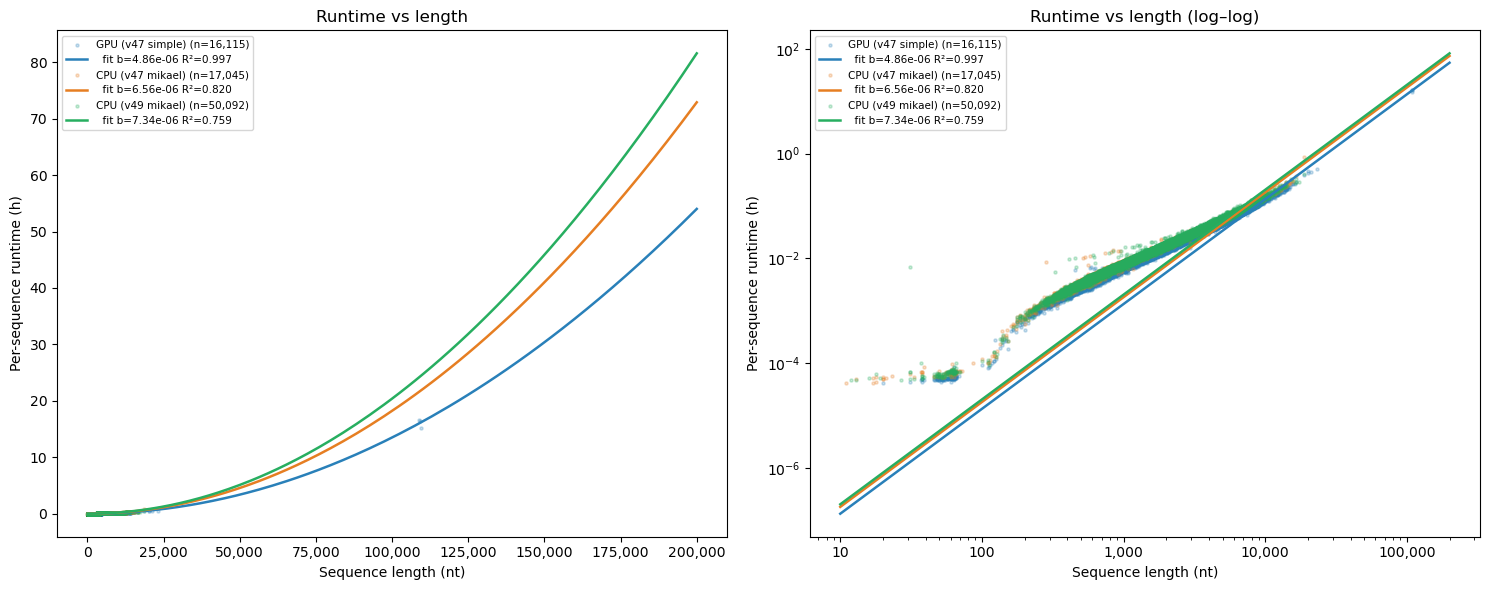

In [ ]:
# Fit O(n²) model to each CPU dataset and compare against GPU
datasets = {
    "GPU (v47 simple)": (df_rt,      "#2980b9"),
    "CPU (v47 mikael)": (df_cpu_v47, "#e67e22"),
    "CPU (v49 mikael)": (df_cpu_v49, "#27ae60"),
}

fits = {}
for label, (df, color) in datasets.items():
    n = df.seq_len_nt.values.astype(float)
    t = df.time_s.values
    popt, _ = curve_fit(model_quadratic, n, t, p0=[1e-9])
    r2 = r2_score(t, model_quadratic(n, *popt))
    fits[label] = {"b": popt[0], "r2": r2, "color": color, "n_seqs": len(df)}
    print(f"{label:25s}  b = {popt[0]:.4e}  R² = {r2:.4f}  n = {len(df):,}")

b_gpu = fits["GPU (v47 simple)"]["b"]
print()
for label, f in fits.items():
    speedup = f["b"] / b_gpu
    print(f"{label:25s}  slowdown vs GPU: {speedup:.1f}×")

# --- Plot ---
n_grid = np.logspace(1, np.log10(200_000), 400)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, log_scale in zip(axes, [False, True]):
    for label, (df, color) in datasets.items():
        ax.scatter(df.seq_len_nt, df.time_s / 3600,
                   alpha=0.25, s=5, color=color, label=f"{label} (n={fits[label]['n_seqs']:,})")
        b = fits[label]["b"]
        ax.plot(n_grid, model_quadratic(n_grid, b) / 3600,
                color=color, linewidth=1.8,
                label=f"  fit b={b:.2e} R²={fits[label]['r2']:.3f}")
    if log_scale:
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_title("Runtime vs length (log–log)")
    else:
        ax.set_title("Runtime vs length")
    ax.set_xlabel("Sequence length (nt)")
    ax.set_ylabel("Per-sequence runtime (h)")
    ax.legend(fontsize=7.5)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("scanfold_gpu_vs_cpu_runtime.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Summary table: coefficients, implied runtime at key lengths, speedup
KEY_N = {"1k nt": 1_000, "5k nt": 5_000, "10k nt": 10_000, "20k nt": 20_000}

rows = []
for label, f in fits.items():
    b = f["b"]
    row = {
        "Dataset": label,
        "Sequences": f"{f['n_seqs']:,}",
        "b (s/nt²)": f"{b:.3e}",
        "R²": f"{f['r2']:.4f}",
        "Slowdown vs GPU": f"{b / b_gpu:.1f}×",
    }
    for key, n in KEY_N.items():
        row[f"t({key})"] = f"{model_quadratic(n, b):.0f} s"
    rows.append(row)

display(pd.DataFrame(rows))

,Dataset,Sequences,b (s/nt²),R²,Slowdown vs GPU,t(1k nt),t(5k nt),t(10k nt),t(20k nt)
0,GPU (v47 simple),"16,115",4.861e-06,0.9966,1.0×,5 s,122 s,486 s,1944 s
1,CPU (v47 mikael),"17,045",6.561e-06,0.8195,1.3×,7 s,164 s,656 s,2625 s
2,CPU (v49 mikael),"50,092",7.342e-06,0.7592,1.5×,7 s,184 s,734 s,2937 s
